KNN CLASSIFIER - PNEUMONIA DETECTION

📂 Loading dataset...
✅ Loaded: 4102 rows × 203 columns

📋 First 5 rows:
                   Image_Name  Label      Class  Feature_1  Feature_2  \
0  BACTERIA-5132924-0001.jpeg      1  Pneumonia -11.545157 -13.717647   
1  BACTERIA-1777631-0001.jpeg      1  Pneumonia  20.818638   8.152621   
2  BACTERIA-7392124-0001.jpeg      1  Pneumonia  30.078508   9.970522   
3  BACTERIA-9072988-0007.jpeg      1  Pneumonia -19.790420  16.773912   
4  BACTERIA-7560163-0001.jpeg      1  Pneumonia -26.874071 -19.328613   

   Feature_3  Feature_4  Feature_5  Feature_6  Feature_7  ...  Feature_191  \
0   2.459949  14.375765  19.150570  -8.340388   6.690397  ...    -2.288996   
1  -1.169066  15.593989   2.154690  18.117068 -13.609882  ...    -2.427195   
2  33.507303 -23.685114  -2.529166  -7.976503 -12.485124  ...    -3.986868   
3  12.641352  25.069962  -2.071930   3.694015   5.166889  ...     0.148843   
4   0.139244  19.195918   3.973868  -8.645415 -20.761864  ...

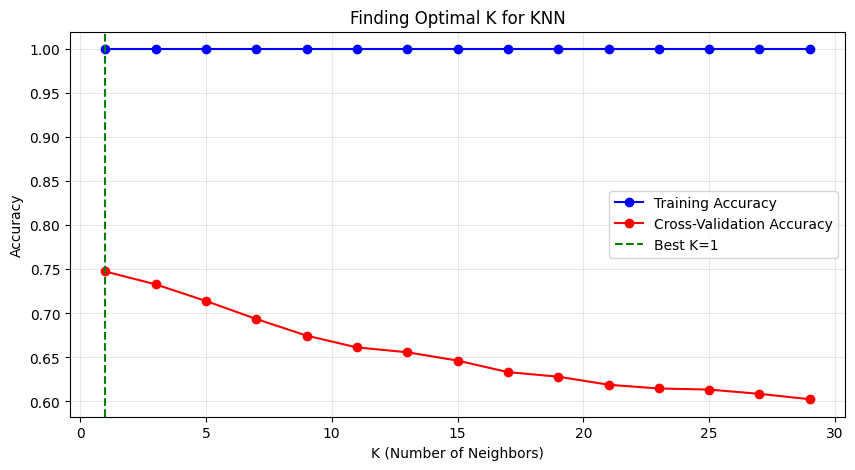


TRAINING KNN
⏳ Training KNN with K=1...
✅ Training complete!

RESULTS

📊 Test Performance:
   Accuracy:   0.7418 (74.2%)
   Precision:  0.9731 (97.3%)
   Recall:     0.6644 (66.4%)
   F1-Score:   0.7897 (79.0%)
   AUC-ROC:    0.8074 (80.7%)

📋 Classification Report:
              precision    recall  f1-score   support

      Normal       0.51      0.95      0.67       222
   Pneumonia       0.97      0.66      0.79       599

    accuracy                           0.74       821
   macro avg       0.74      0.81      0.73       821
weighted avg       0.85      0.74      0.76       821


🏥 Medical Metrics:
   Correct Normal:     211
   False Alarms:       11
   Missed Pneumonia:   201 ⚠️
   Caught Pneumonia:   398
   Sensitivity:        0.6644 (66.4%)
   Specificity:        0.9505 (95.0%)
   PPV (Precision):    0.9731 (97.3%)
   NPV:                0.5121 (51.2%)


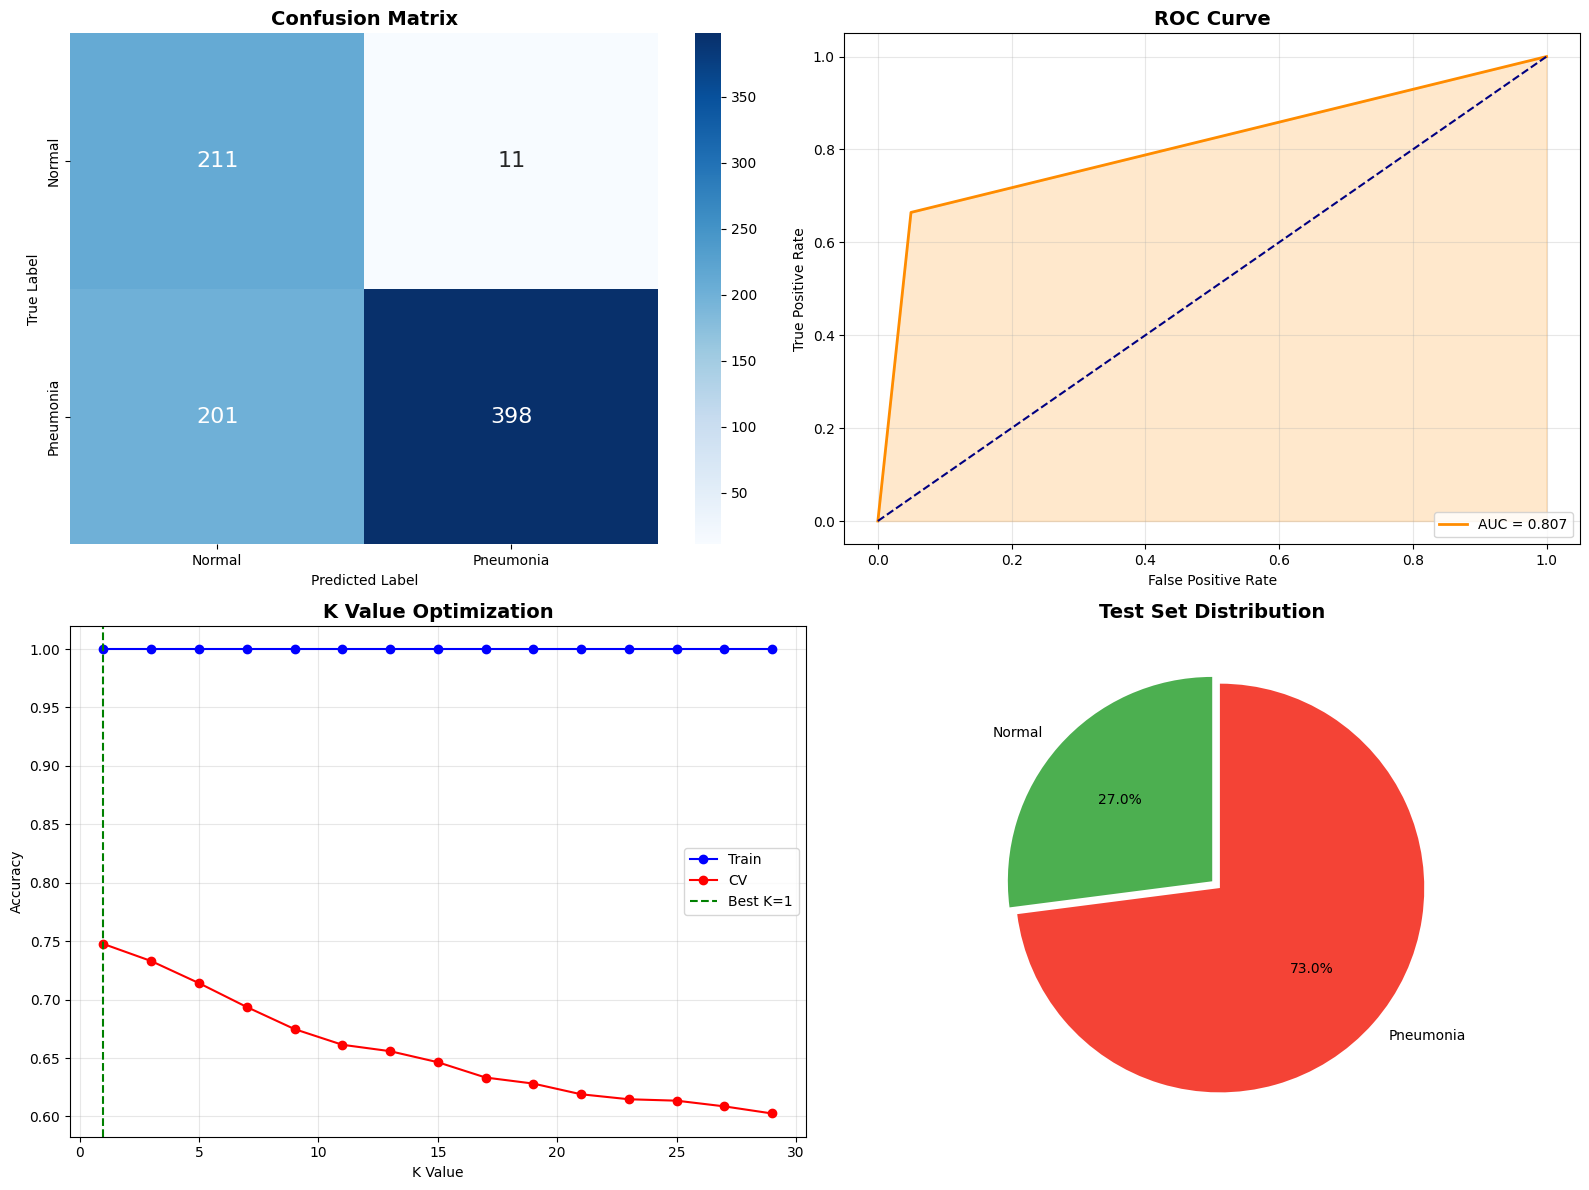


NEIGHBOR ANALYSIS

   Sample 1: True=Pneumonia, Predicted=Pneumonia
   Neighbor distances: ['14.950', '14.971', '15.090', '15.104', '15.124']
   Neighbor labels:    [1, 1, 1, 1, 1]
   Decision:           Pneumonia

   Sample 2: True=Pneumonia, Predicted=Pneumonia
   Neighbor distances: ['13.719', '14.977', '15.360', '15.620', '15.843']
   Neighbor labels:    [1, 1, 1, 1, 0]
   Decision:           Pneumonia

   Sample 3: True=Normal, Predicted=Normal
   Neighbor distances: ['13.827', '14.133', '14.506', '14.597', '14.605']
   Neighbor labels:    [0, 0, 0, 0, 0]
   Decision:           Normal

   Sample 4: True=Pneumonia, Predicted=Pneumonia
   Neighbor distances: ['12.040', '12.943', '13.227', '13.361', '13.429']
   Neighbor labels:    [1, 0, 0, 0, 0]
   Decision:           Normal

   Sample 5: True=Normal, Predicted=Pneumonia
   Neighbor distances: ['15.022', '15.293', '15.301', '15.461', '15.545']
   Neighbor labels:    [1, 0, 0, 0, 0]
   Decision:           Normal

MODEL SUMMARY

🔧 K

In [1]:
# ============================================
# KNN CLASSIFIER - PNEUMONIA DETECTION
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                           accuracy_score, precision_score, recall_score,
                           f1_score, roc_auc_score, roc_curve)
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("KNN CLASSIFIER - PNEUMONIA DETECTION")
print("="*60)

# ============================================
# 1. LOAD THE CSV DATASET
# ============================================

csv_path = '/kaggle/input/datasets/mtishakil/chest-x-ray-feature-extracted-dataset-for-ml/Chest X-Ray Feature Extracted Dataset for ML.csv'

print(f"\n📂 Loading dataset...")
df = pd.read_csv(csv_path)
print(f"✅ Loaded: {df.shape[0]} rows × {df.shape[1]} columns")

print(f"\n📋 First 5 rows:")
print(df.head())

print(f"\n📊 Class Distribution:")
print(df['Class'].value_counts())
print(f"   Normal:     {len(df[df['Label']==0])}")
print(f"   Pneumonia:  {len(df[df['Label']==1])}")

# ============================================
# 2. PREPARE FEATURES AND TARGET
# ============================================

print("\n" + "="*60)
print("DATA PREPARATION")
print("="*60)

X = df.drop(['Image_Name', 'Label', 'Class'], axis=1)
y = df['Label']

print(f"\n✅ Features: {X.shape[1]} columns")
print(f"✅ Target: {len(y)} samples")

# ============================================
# 3. TRAIN-TEST SPLIT
# ============================================

print("\n" + "="*60)
print("TRAIN-TEST SPLIT")
print("="*60)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"\n✅ Training: {len(X_train)} samples")
print(f"   Normal: {np.sum(y_train==0)}, Pneumonia: {np.sum(y_train==1)}")
print(f"✅ Testing:  {len(X_test)} samples")
print(f"   Normal: {np.sum(y_test==0)}, Pneumonia: {np.sum(y_test==1)}")

# ============================================
# 4. FEATURE SCALING (CRITICAL for KNN!)
# ============================================

print("\n" + "="*60)
print("FEATURE SCALING")
print("="*60)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Features scaled (StandardScaler)")
print(f"   Train mean: {X_train_scaled.mean():.4f}")
print(f"   Train std:  {X_train_scaled.std():.4f}")

# ============================================
# 5. FIND OPTIMAL K VALUE
# ============================================

print("\n" + "="*60)
print("FINDING OPTIMAL K")
print("="*60)

k_values = range(1, 31, 2)
cv_scores = []
train_scores = []

print("⏳ Testing different K values...")
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance', n_jobs=-1)
    knn.fit(X_train_scaled, y_train)
    
    # Cross-validation score
    cv_score = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy').mean()
    cv_scores.append(cv_score)
    
    # Training score
    train_score = knn.score(X_train_scaled, y_train)
    train_scores.append(train_score)

# Find best K
best_k = k_values[np.argmax(cv_scores)]
print(f"\n✅ Best K: {best_k}")
print(f"   Best CV Score: {max(cv_scores):.4f}")

# Plot K vs Accuracy
plt.figure(figsize=(10, 5))
plt.plot(k_values, train_scores, 'o-', label='Training Accuracy', color='blue')
plt.plot(k_values, cv_scores, 'o-', label='Cross-Validation Accuracy', color='red')
plt.axvline(x=best_k, color='green', linestyle='--', label=f'Best K={best_k}')
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Accuracy')
plt.title('Finding Optimal K for KNN')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ============================================
# 6. TRAIN FINAL KNN MODEL
# ============================================

print("\n" + "="*60)
print("TRAINING KNN")
print("="*60)

knn_model = KNeighborsClassifier(
    n_neighbors=best_k,
    weights='distance',      # Closer neighbors have more influence
    metric='minkowski',      # Distance metric
    p=2,                     # Euclidean distance
    n_jobs=-1
)

print(f"⏳ Training KNN with K={best_k}...")
knn_model.fit(X_train_scaled, y_train)
print("✅ Training complete!")

# ============================================
# 7. EVALUATE
# ============================================

print("\n" + "="*60)
print("RESULTS")
print("="*60)

y_pred = knn_model.predict(X_test_scaled)
y_prob = knn_model.predict_proba(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob[:, 1])

print(f"\n📊 Test Performance:")
print(f"   Accuracy:   {accuracy:.4f} ({accuracy*100:.1f}%)")
print(f"   Precision:  {precision:.4f} ({precision*100:.1f}%)")
print(f"   Recall:     {recall:.4f} ({recall*100:.1f}%)")
print(f"   F1-Score:   {f1:.4f} ({f1*100:.1f}%)")
print(f"   AUC-ROC:    {auc:.4f} ({auc*100:.1f}%)")

print(f"\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Pneumonia']))

# ============================================
# 8. CONFUSION MATRIX & MEDICAL METRICS
# ============================================

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"\n🏥 Medical Metrics:")
print(f"   Correct Normal:     {tn}")
print(f"   False Alarms:       {fp}")
print(f"   Missed Pneumonia:   {fn} {'⚠️' if fn>0 else '✅'}")
print(f"   Caught Pneumonia:   {tp}")
print(f"   Sensitivity:        {tp/(tp+fn):.4f} ({tp/(tp+fn)*100:.1f}%)")
print(f"   Specificity:        {tn/(tn+fp):.4f} ({tn/(tn+fp)*100:.1f}%)")
print(f"   PPV (Precision):    {tp/(tp+fp):.4f} ({tp/(tp+fp)*100:.1f}%)")
print(f"   NPV:                {tn/(tn+fn):.4f} ({tn/(tn+fn)*100:.1f}%)")

# ============================================
# 9. VISUALIZATIONS
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'],
            annot_kws={'size': 16})
axes[0, 0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('True Label')
axes[0, 0].set_xlabel('Predicted Label')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob[:, 1])
axes[0, 1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {auc:.3f}')
axes[0, 1].plot([0, 1], [0, 1], '--', color='navy')
axes[0, 1].fill_between(fpr, tpr, alpha=0.2, color='darkorange')
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[0, 1].legend(loc="lower right")
axes[0, 1].grid(True, alpha=0.3)

# K Value Performance
axes[1, 0].plot(k_values, train_scores, 'o-', label='Train', color='blue')
axes[1, 0].plot(k_values, cv_scores, 'o-', label='CV', color='red')
axes[1, 0].axvline(x=best_k, color='green', linestyle='--', label=f'Best K={best_k}')
axes[1, 0].set_xlabel('K Value')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_title('K Value Optimization', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Class Distribution Pie
class_counts = [np.sum(y_test==0), np.sum(y_test==1)]
axes[1, 1].pie(class_counts, labels=['Normal', 'Pneumonia'], autopct='%1.1f%%',
            colors=['#4CAF50', '#F44336'], explode=(0, 0.05), startangle=90)
axes[1, 1].set_title('Test Set Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================
# 10. DISTANCE ANALYSIS
# ============================================

print("\n" + "="*60)
print("NEIGHBOR ANALYSIS")
print("="*60)

# Get distances to nearest neighbors for a few test samples
sample_indices = np.random.choice(len(X_test_scaled), min(5, len(X_test_scaled)), replace=False)

for i, idx in enumerate(sample_indices):
    distances, neighbors = knn_model.kneighbors([X_test_scaled[idx]], n_neighbors=5)
    neighbor_labels = y_train.iloc[neighbors[0]]
    
    true_label = "Pneumonia" if y_test.iloc[idx] == 1 else "Normal"
    pred_label = "Pneumonia" if y_pred[idx] == 1 else "Normal"
    
    print(f"\n   Sample {i+1}: True={true_label}, Predicted={pred_label}")
    print(f"   Neighbor distances: {[f'{d:.3f}' for d in distances[0]]}")
    print(f"   Neighbor labels:    {list(neighbor_labels)}")
    print(f"   Decision:           {'Pneumonia' if np.mean(neighbor_labels) > 0.5 else 'Normal'}")

# ============================================
# 11. MODEL SUMMARY
# ============================================

print("\n" + "="*60)
print("MODEL SUMMARY")
print("="*60)

print(f"\n🔧 KNN Parameters:")
print(f"   K (Neighbors):  {knn_model.n_neighbors}")
print(f"   Weights:        {knn_model.weights}")
print(f"   Metric:         {knn_model.metric}")
print(f"   Algorithm:      {knn_model.algorithm}")

print(f"\n📈 Final Test Performance:")
print(f"   Accuracy:   {accuracy:.4f} ({accuracy*100:.1f}%)")
print(f"   Precision:  {precision:.4f} ({precision*100:.1f}%)")
print(f"   Recall:     {recall:.4f} ({recall*100:.1f}%)")
print(f"   F1-Score:   {f1:.4f} ({f1*100:.1f}%)")
print(f"   AUC-ROC:    {auc:.4f} ({auc*100:.1f}%)")

print(f"\n💡 KNN Characteristics:")
print(f"   ✅ Simple & interpretable")
print(f"   ✅ No training time (lazy learner)")
print(f"   ⚠️  Slow prediction on large datasets")
print(f"   ⚠️  Sensitive to feature scaling")
print(f"   ⚠️  Curse of dimensionality")

print("\n" + "="*60)
print("✅ KNN CLASSIFICATION COMPLETE!")
print("="*60)